In [3]:
import pandas as pd
df=pd.read_csv("../mall Customers.csv")
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [4]:
import pandas as pd
import numpy as np
df=pd.read_csv("../mall Customers.csv")
print(df.head())
print()
print(df.describe())
print()
print(df.info())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000      

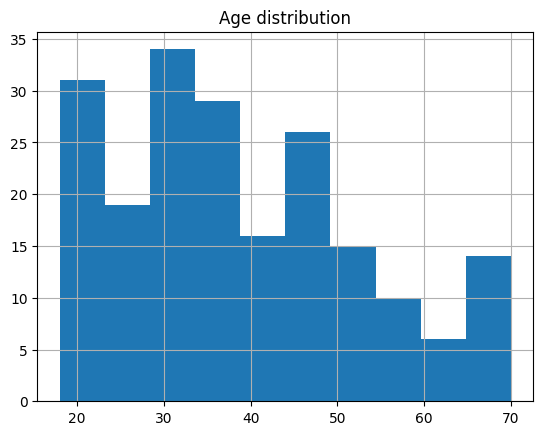

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
df["Age"].hist()
plt.title("Age distribution")
plt.show()

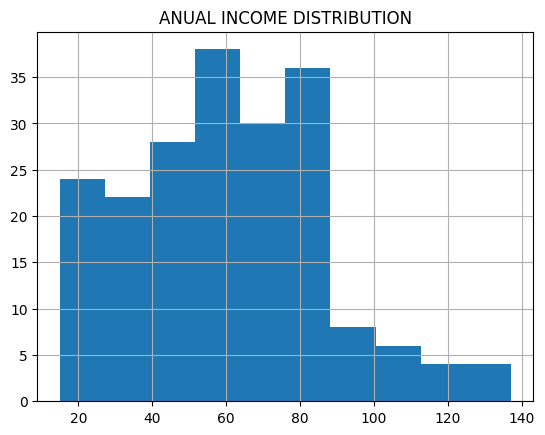

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("../mall customers.csv")
df["Annual Income (k$)"].hist()
plt.title("ANUAL INCOME DISTRIBUTION")
plt.show()

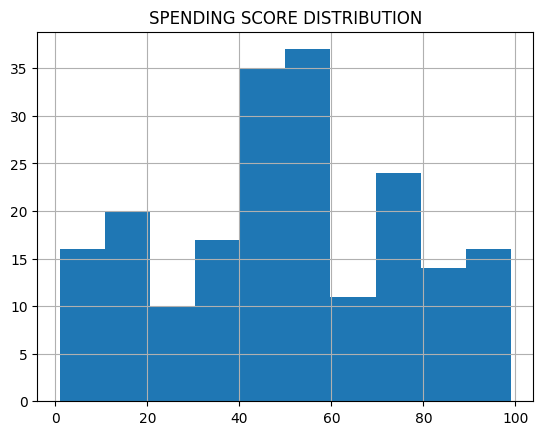

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("../mall customers.csv")
df["Spending Score (1-100)"].hist()
plt.title("SPENDING SCORE DISTRIBUTION")
plt.show()

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
x=df[["Annual Income (k$)","Spending Score (1-100)"]]
kmeans=KMeans(n_clusters=5,random_state=42)
df["cluster"]=kmeans.fit_predict(x)
print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


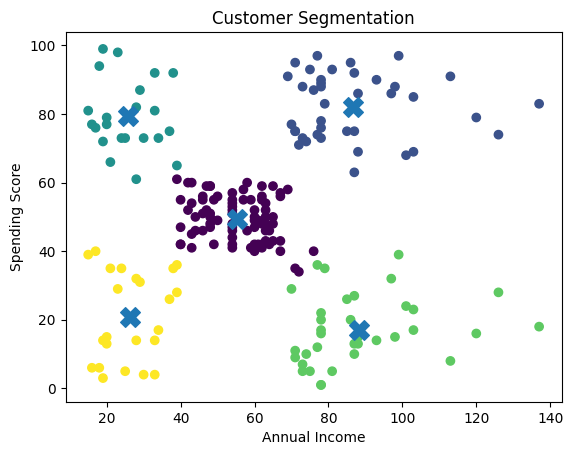

In [13]:
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["cluster"]
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1], 
    s=200,
    marker="X"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

In [54]:
df=pd.read_csv("../mall customers.csv")
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [55]:
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [17]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

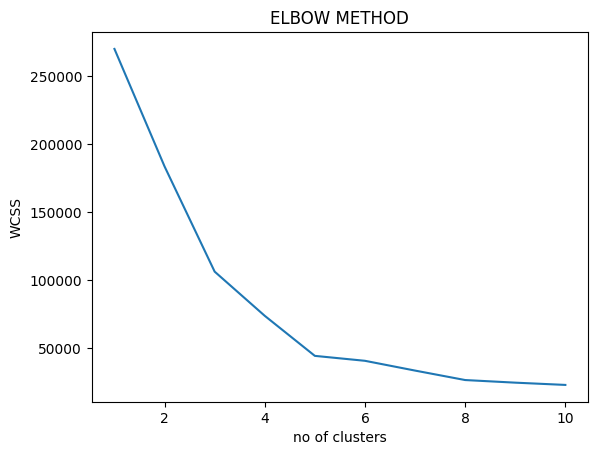

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss)
plt.xlabel("no of clusters")
plt.ylabel("WCSS")
plt.title("ELBOW METHOD")
plt.savefig("elbow_method.png")
plt.show()

In [39]:
df.groupby("cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [40]:
print(df["cluster"].value_counts())

cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


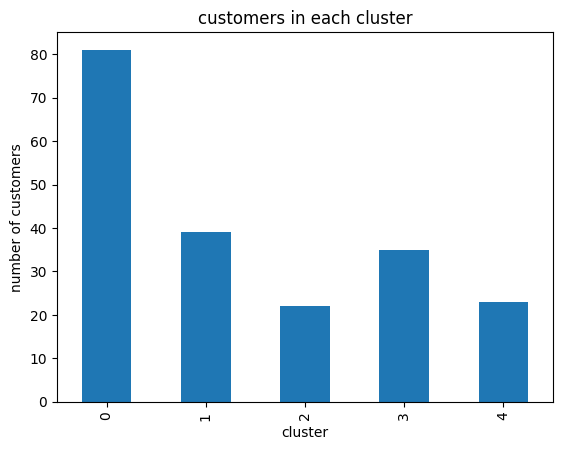

In [43]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("customers in each cluster")
plt.xlabel("cluster")
plt.ylabel("number of customers")
plt.show()


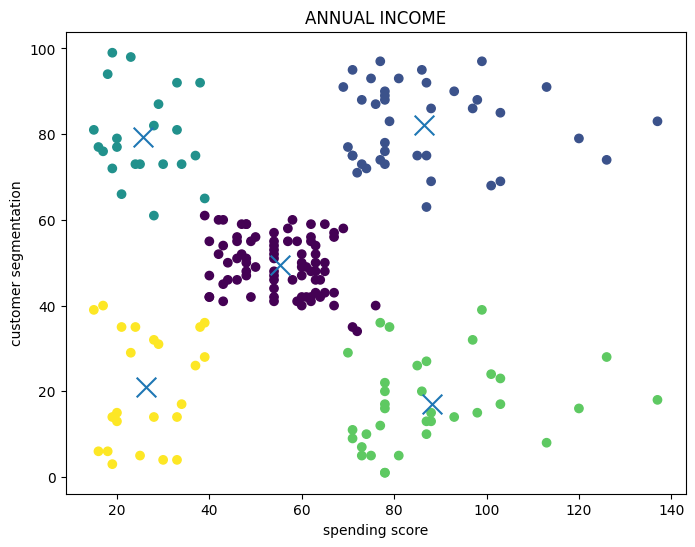

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["cluster"]
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker="x"
)
plt.title("ANNUAL INCOME")
plt.xlabel("spending score")
plt.ylabel("customer segmentation")
plt.savefig("customer_segments png")
plt.show()